# Trending Skills Analysis in Germany

## Executive Summary

This notebook analyzes monthly demand trends for **Data Engineer** skills in **Germany** during 2023 using the **Data Jobs** dataset from Hugging Face.

The goal is to identify the most frequently requested Data Engineering skills and evaluate how demand for those skills changed throughout the year.

Skill demand is approximated using the number of job advertisements mentioning a particular skill.

## Business Questions

- Which skills are most frequently advertised for Data Engineer roles in Germany?
- How does skill demand change throughout the year?
- Which months show the peak and lowest hiring activity?
- What patterns can be observed among the most demanded skills?

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Dataset Overview

The Data Jobs dataset contains job postings collected from multiple online sources.

For this analysis:

- Only **German** job postings are considered.
- Only **Data Engineer** roles are analyzed.
- Posting dates are converted into monthly periods.
- Skill demand is measured by the number of job advertisements mentioning each skill.

In [2]:
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 785,741
Columns: 17


## Data Preparation

The posting date is converted into datetime format and the dataset is filtered to include only Data Engineer jobs located in Germany.

The skills column is converted from text representation into Python lists for analysis.

In [3]:
def parse_skill_list(value):
    """Convert the raw skills field into a normalized list of lowercase skills."""
    if isinstance(value, list):
        return [str(skill).strip().lower() for skill in value if str(skill).strip()]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(skill).strip().lower() for skill in parsed if str(skill).strip()]
        except (ValueError, SyntaxError):
            pass
        return [skill.strip().lower() for skill in value.split(",") if skill.strip()]
    return []

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(parse_skill_list)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_de = df[
    (df["job_title_short"] == "Data Engineer") &
    (df["job_country"] == "Germany")
].copy()

df_de["job_posted_month"] = pd.Categorical(
    df_de["job_posted_date"].dt.strftime("%b"),
    categories=month_order,
    ordered=True
)

print(f"German Data Engineer postings: {len(df_de):,}")

German Data Engineer postings: 6,675


## Data Quality Check

The filtered dataset is inspected for missing values and overall completeness before further analysis.

In [4]:
quality_summary = pd.DataFrame({
    "Missing Values": df_de.isna().sum(),
    "Missing (%)": (df_de.isna().mean() * 100).round(2)
}).sort_values("Missing Values", ascending=False)

quality_summary

,Missing Values,Missing (%)
salary_hour_avg,6675,100.00
salary_rate,6636,99.42
salary_year_avg,6636,99.42
job_type_skills,1143,17.12
job_schedule_type,19,0.28
job_location,1,0.01
job_title,0,0.00
job_title_short,0,0.00
job_via,0,0.00
job_work_from_home,0,0.00


### Interpretation

The dataset is highly complete for skills, job titles, and posting dates, providing a reliable foundation for trend analysis.

Salary-related fields contain substantial missing values and are therefore excluded from subsequent analysis. The analysis focuses on skills, hiring activity, and job posting trends, where data completeness is high.

### Sample Records

The table below shows a random sample of Data Engineer job postings after filtering for Germany.

In [5]:
df_de[
    [
        "job_title_short",
        "job_country",
        "job_posted_date",
        "job_posted_month",
        "job_skills",
    ]
].sample(10, random_state=42)

,job_title_short,job_country,job_posted_date,job_posted_month,job_skills
190813,Data Engineer,Germany,2023-12-22 15:18:40,Dec,"[sql, python, snowflake, azure, tableau, power..."
756103,Data Engineer,Germany,2023-08-18 20:28:09,Aug,"[python, tableau]"
551016,Data Engineer,Germany,2023-02-09 03:15:47,Feb,"[python, sql, nosql, java, scala, elasticsearc..."
271634,Data Engineer,Germany,2023-11-19 07:18:02,Nov,"[sql, snowflake, power bi, excel]"
166278,Data Engineer,Germany,2023-08-27 15:21:31,Aug,"[sql, no-sql, azure, databricks, airflow, exce..."
691468,Data Engineer,Germany,2023-11-18 10:35:09,Nov,[]
156690,Data Engineer,Germany,2023-09-29 08:15:30,Sep,[]
172255,Data Engineer,Germany,2023-02-12 15:36:34,Feb,"[python, ruby, ruby, mongodb, mongodb, heroku,..."
307538,Data Engineer,Germany,2023-09-28 17:51:18,Sep,"[python, sql, azure, pandas, airflow, sap]"
463796,Data Engineer,Germany,2023-03-14 14:19:10,Mar,"[python, sql, nosql, aws, gcp]"


## Executive Metrics

This section summarizes the most important figures from the German Data Engineer segment.

In [6]:
skill_counts = (
    df_de["job_skills"]
    .explode()
    .dropna()
    .value_counts()
)

total_postings = len(df_de)
unique_skills = skill_counts.shape[0]
top_skill = skill_counts.index[0]
top_skill_display = top_skill.title()
top_skill_count = skill_counts.iloc[0]

monthly_postings = (
    df_de["job_posted_month"]
    .value_counts()
    .reindex(month_order)
)

peak_month = monthly_postings.idxmax()
lowest_month = monthly_postings.idxmin()

metrics = pd.DataFrame({
    "Metric": [
        "Total German Data Engineer Postings",
        "Unique Skills Observed",
        "Most Requested Skill",
        "Mentions for Top Skill",
        "Peak Hiring Month",
        "Lowest Hiring Month",
    ],
    "Value": [
        f"{total_postings:,}",
        f"{unique_skills:,}",
        top_skill_display,
        f"{top_skill_count:,}",
        peak_month,
        lowest_month,
    ],
})

(
    metrics.style
    .hide(axis="index")
)

Metric,Value
Total German Data Engineer Postings,"6,675"
Unique Skills Observed,192
Most Requested Skill,Python
Mentions for Top Skill,"3,524"
Peak Hiring Month,Oct
Lowest Hiring Month,May


## Hiring Activity by Month

The chart below shows how Data Engineer hiring activity varied throughout 2023 in Germany.

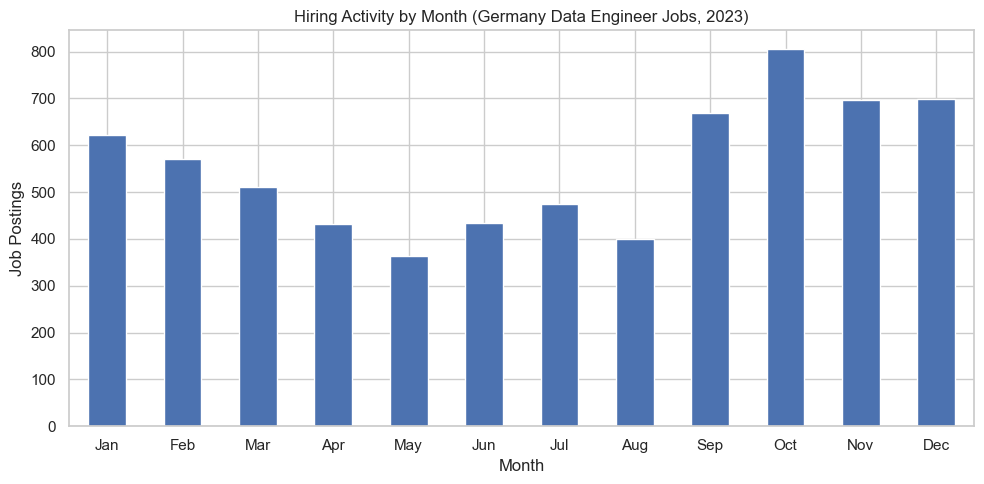

In [7]:
plt.figure(figsize=(10, 5))

monthly_postings.plot(kind="bar")

plt.title("Hiring Activity by Month (Germany Data Engineer Jobs, 2023)")
plt.xlabel("Month")
plt.ylabel("Job Postings")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Top Skills

The table below ranks the most frequently requested skills appearing in German Data Engineer job postings during 2023.

Python and SQL dominate the market, while cloud and distributed processing technologies remain highly represented.

In [8]:
top_skills_table = skill_counts.head(10).reset_index()
top_skills_table.columns = ["Skill", "Mentions"]
top_skills_table["Skill"] = top_skills_table["Skill"].str.title()
top_skills_table.index = top_skills_table.index + 1

top_skills_table

,Skill,Mentions
1,Python,3524
2,Sql,3145
3,Azure,1961
4,Aws,1649
5,Spark,1341
6,Java,1197
7,Kafka,883
8,Airflow,823
9,Databricks,794
10,Scala,717


## Skill Popularity

This chart compares the number of job postings mentioning the ten most demanded Data Engineering skills in Germany.

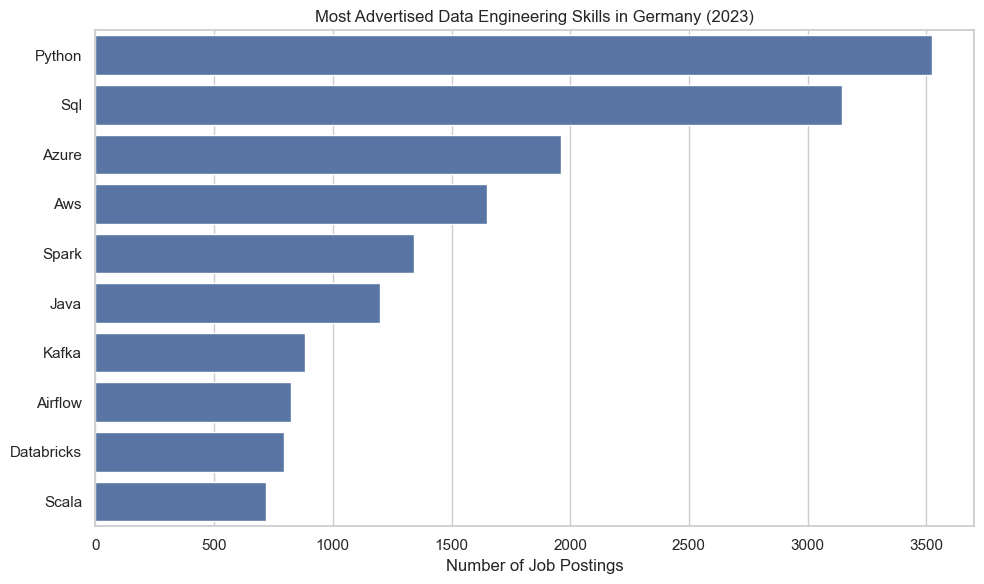

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_skills_table,
    x="Mentions",
    y="Skill"
)

plt.title("Most Advertised Data Engineering Skills in Germany (2023)")
plt.xlabel("Number of Job Postings")
plt.ylabel("")

plt.tight_layout()
plt.show()

## Monthly Skill Aggregation

Each posting may include multiple skills.

The skills column is exploded so that each skill becomes a separate observation.

A pivot table is then created to calculate monthly demand for every skill.

In [10]:
df_de_explode = df_de.explode("job_skills").dropna(subset=["job_skills"])

monthly_skill_counts = (
    df_de_explode
    .groupby(["job_posted_month", "job_skills"])
    .size()
    .reset_index(name="skill_mentions")
)

skill_pivot = monthly_skill_counts.pivot_table(
    index="job_posted_month",
    columns="job_skills",
    values="skill_mentions",
    aggfunc="sum",
    fill_value=0,
)

skill_pivot = skill_pivot.reindex(month_order)

top_5_skills = skill_pivot.sum().sort_values(ascending=False).head(5).index.tolist()

plot_data = skill_pivot[top_5_skills].reset_index()

plot_data["job_posted_month"] = pd.Categorical(
    plot_data["job_posted_month"],
    categories=month_order,
    ordered=True
)

plot_data = plot_data.sort_values("job_posted_month")

plot_data.columns.name = None

plot_data.style.hide(axis="index")

job_posted_month,python,sql,azure,aws,spark
Jan,329,316,214,181,152
Feb,312,252,177,144,146
Mar,287,256,144,135,99
Apr,267,225,125,134,114
May,212,167,121,106,69
Jun,246,219,134,119,96
Jul,269,213,150,141,92
Aug,187,177,118,80,83
Sep,337,315,197,145,131
Oct,416,382,224,177,156


## Skill Demand Trends

The chart below displays the five most frequently requested Data Engineer skills in Germany and how their demand evolved throughout 2023.

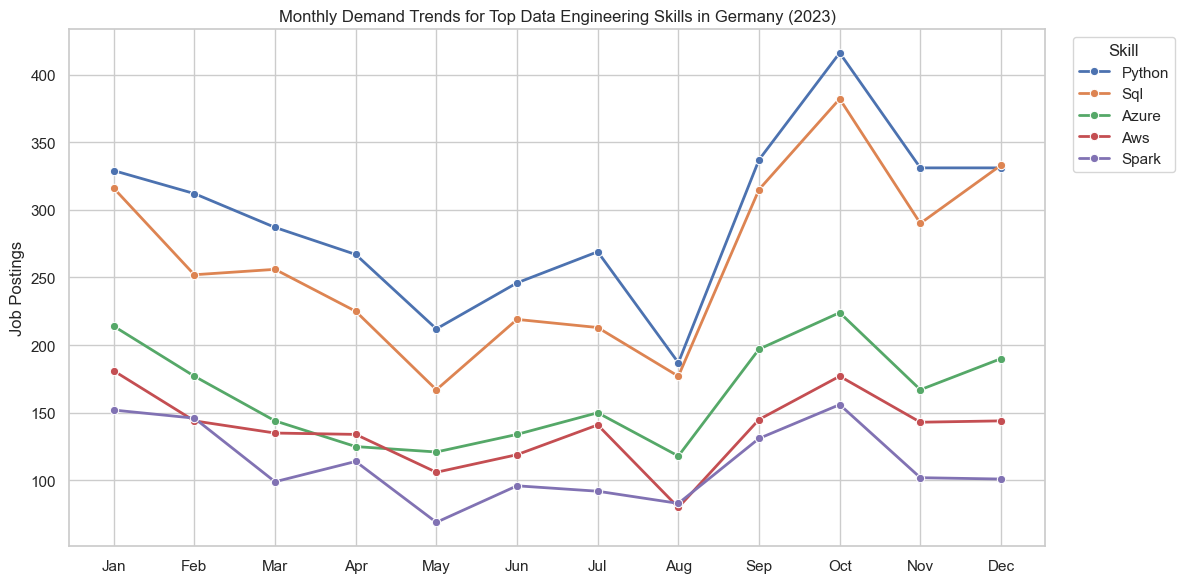

In [11]:
plt.figure(figsize=(12, 6))

for skill in top_5_skills:
    sns.lineplot(
        data=plot_data,
        x="job_posted_month",
        y=skill,
        marker="o",
        linewidth=2,
        label=skill.title(),
    )

plt.title("Monthly Demand Trends for Top Data Engineering Skills in Germany (2023)")
plt.xlabel("")
plt.ylabel("Job Postings")
plt.xticks(rotation=0)
plt.legend(title="Skill", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Skill Demand Heatmap

The heatmap highlights seasonal demand patterns across the five most frequently requested skills.

Darker cells indicate higher numbers of job postings mentioning a skill during a particular month.

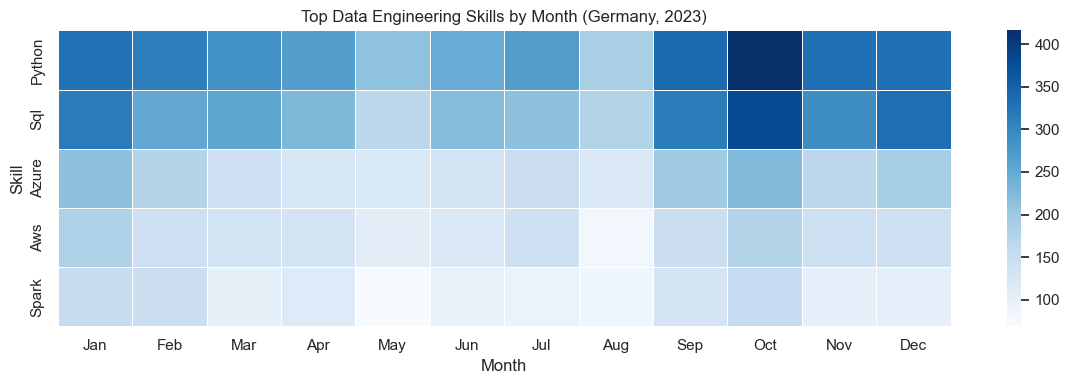

In [12]:
heatmap_data = skill_pivot[top_5_skills].T.copy()
heatmap_data.index = heatmap_data.index.str.title()

plt.figure(figsize=(12, 4))

sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=False,
    linewidths=0.5
)

plt.title("Top Data Engineering Skills by Month (Germany, 2023)")
plt.xlabel("Month")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

## Key Findings

1. Python was the most requested skill overall, appearing in 3,524 German Data Engineer job postings.
2. SQL demonstrated similarly strong demand throughout the year, confirming its position as a foundational Data Engineering capability.
3. Cloud platforms such as Azure and AWS were consistently requested, highlighting the importance of cloud-native data infrastructure.
4. Spark remained one of the leading distributed processing technologies, indicating continued demand for large-scale data processing skills.
5. Hiring activity reached its highest level during October and was weakest in May.

## Recommendations

Based on observed hiring patterns, candidates targeting Data Engineer positions in Germany should prioritize development of the following capabilities:

1. Python
2. SQL
3. Azure
4. AWS
5. Spark

A competitive profile combines programming, database, cloud, and distributed data processing skills rather than focusing on a single technology.

## Limitations

- The analysis uses only job postings available within the Data Jobs dataset.
- Job posting counts measure hiring demand indirectly and do not represent actual hires.
- The study focuses exclusively on Germany and may not generalize to other markets.
- Results are based on 2023 postings and may not reflect current labor market conditions.
- Skills are extracted from posting text, so normalization choices can affect counts.

## Conclusion

This analysis examined 6,675 German Data Engineer job postings from 2023 to identify the most frequently requested skills and evaluate how their demand changed throughout the year.

The results suggest sustained demand for foundational technologies such as SQL and Python, with cloud and distributed data tools remaining relevant throughout the year. Although hiring activity fluctuated across months, the relative importance of core data engineering skills remained stable.

Overall, the findings indicate that employers in Germany consistently prioritized capabilities related to data processing, infrastructure, and analytics engineering.